### Exploratory Data Analysis using Visualization

### Instructions
**Students must:**
- Load the Titanic dataset.
- Perform basic data exploration using info() and describe().
- Handle missing values if necessary.
- Create the required visualizations.
- Add title and axis labels to each chart.
- Write interpretation for each visualization.
- Write final insights from the dataset.

In [43]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Loading the Titanic dataset.
df = pd.read_csv('Titanic.csv')

# Performing basic data exploration using info() and describe().
print(df.info())
print(df.describe())

# Handling missing values.
df['Age'] = df['Age'].fillna(df['Age'].median())

df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

df.drop(columns=['Cabin'], inplace=True)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB
None
       PassengerId    Survived      Pclass         Age       SibSp  \
count   891.000000  891.000000  891.000000  714.000000  891.000000   
mean    446.000000    0.383838    2.308642   29.699118    0.523008   
std     257.353842    0.48659

### Assignment Questions (Visualization Based)
**Q1. Create a countplot to show the number of passengers by gender.**

C:\Users\DELL\AppData\Local\Temp\ipykernel_7096\3604092858.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Sex', data=df, palette='Set1')


Text(0, 0.5, 'Passenger Count')

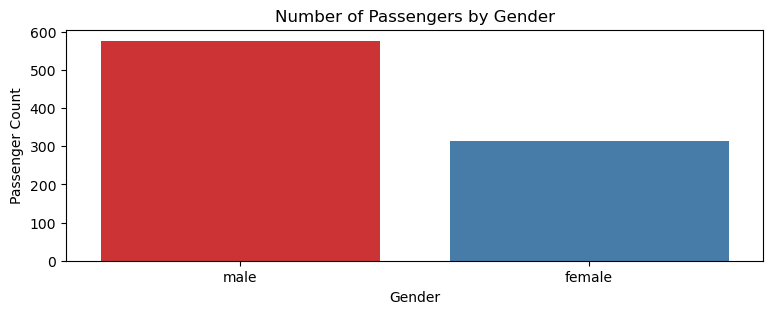

In [44]:
plt.figure(figsize=(9, 3))
sns.countplot(x='Sex', data=df, palette='Set1')

plt.title('Number of Passengers by Gender')
plt.xlabel('Gender')
plt.ylabel('Passenger Count')


**Q2. Create a bar chart to show the number of passengers in each passenger class using different colors.**

C:\Users\DELL\AppData\Local\Temp\ipykernel_7096\2297734933.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Pclass', data=df, palette='Set1')


Text(0, 0.5, 'Number of Passengers')

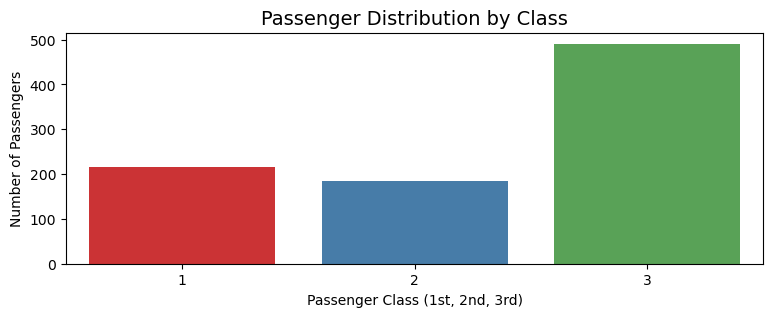

In [45]:
plt.figure(figsize=(9, 3))
sns.countplot(x='Pclass', data=df, palette='Set1')

plt.title('Passenger Distribution by Class', fontsize=14)
plt.xlabel('Passenger Class (1st, 2nd, 3rd)')
plt.ylabel('Number of Passengers')

**Q3. Create a histogram to show the distribution of passenger age.**

Text(0, 0.5, 'Frequency')

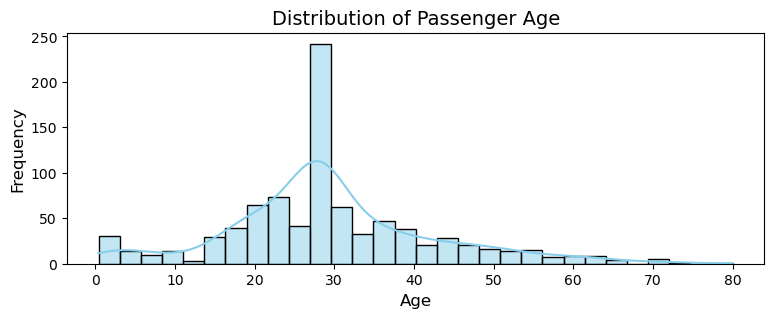

In [46]:
plt.figure(figsize=(9, 3))
sns.histplot(df['Age'], bins=30, kde=True, color='skyblue', edgecolor='black')

plt.title('Distribution of Passenger Age', fontsize=14)
plt.xlabel('Age', fontsize=12)
plt.ylabel('Frequency', fontsize=12)

**Q4. Create a boxplot to detect outliers in the fare column.**

Text(0.5, 0, 'Fare')

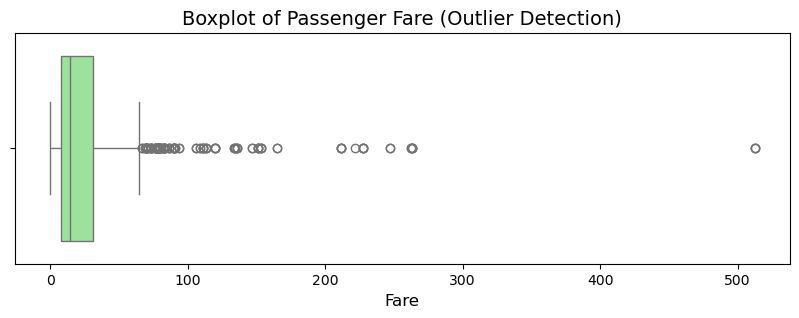

In [47]:
plt.figure(figsize=(10, 3))
sns.boxplot(x=df['Fare'], color='lightgreen')

plt.title('Boxplot of Passenger Fare (Outlier Detection)', fontsize=14)
plt.xlabel('Fare', fontsize=12)

**Q5. Create a scatterplot to:**
- a. show the relationship between age and fare.
- b. analyze the relationship between family size (SibSp + Parch) and fare.

Text(0, 0.5, 'Fare')

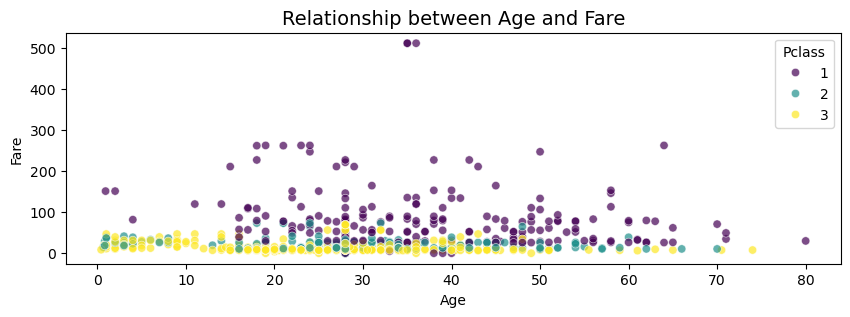

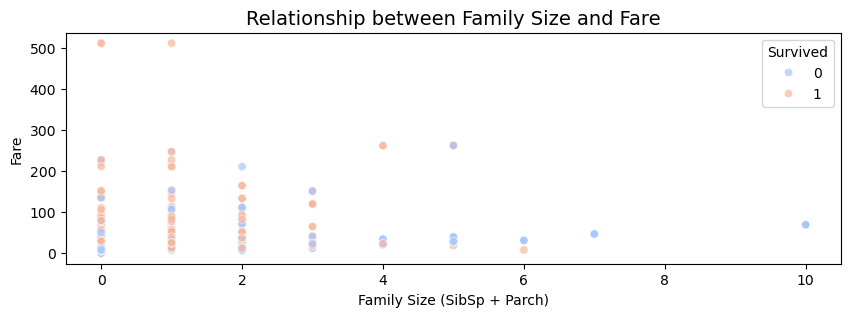

In [48]:
# a. The relationship between age and fare.
plt.figure(figsize=(10, 3))
sns.scatterplot(x='Age', y='Fare', data=df, hue='Pclass', palette='viridis', alpha=0.7)
plt.title('Relationship between Age and Fare', fontsize=14)
plt.xlabel('Age')
plt.ylabel('Fare')



# b. Analyze the relationship between family size (SibSp + Parch) and fare.
df['FamilySize'] = df['SibSp'] + df['Parch']

plt.figure(figsize=(10, 3))
sns.scatterplot(x='FamilySize', y='Fare', data=df, hue='Survived', palette='coolwarm', alpha=0.7)
plt.title('Relationship between Family Size and Fare', fontsize=14)
plt.xlabel('Family Size (SibSp + Parch)')
plt.ylabel('Fare')

**Q6. Create a countplot to show survival count by gender.**

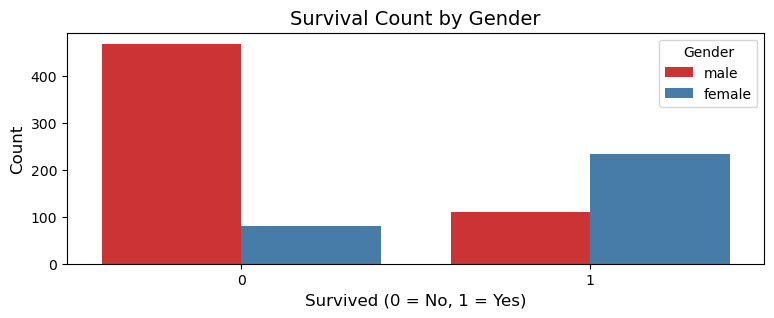

In [49]:

plt.figure(figsize=(9, 3))
sns.countplot(data=df, x='Survived', hue='Sex', palette='Set1')
plt.title('Survival Count by Gender', fontsize=14)
plt.xlabel('Survived (0 = No, 1 = Yes)', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.legend(title='Gender')

**Q7. Create a bar chart to show survival by passenger class.**

C:\Users\DELL\AppData\Local\Temp\ipykernel_7096\3499460237.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=survivalRateByClass, x='Pclass', y='Survived', palette='viridis')


Text(0, 0.5, 'Survival Probability')

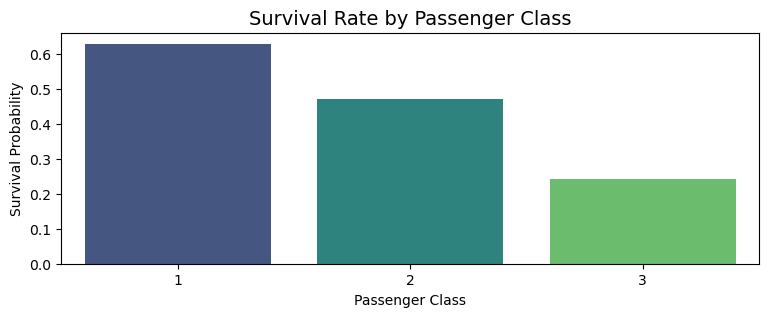

In [50]:
plt.figure(figsize=(9, 3))

survivalRateByClass = df.groupby('Pclass')['Survived'].mean().reset_index().sort_values(by='Survived', ascending=False)
sns.barplot(data=survivalRateByClass, x='Pclass', y='Survived', palette='viridis')

plt.title('Survival Rate by Passenger Class', fontsize=14)
plt.xlabel('Passenger Class')
plt.ylabel('Survival Probability')

**Q8. Create a heatmap to show correlation between numerical variables.**

Text(0.5, 1.0, 'Correlation Heatmap of Numerical Variables')

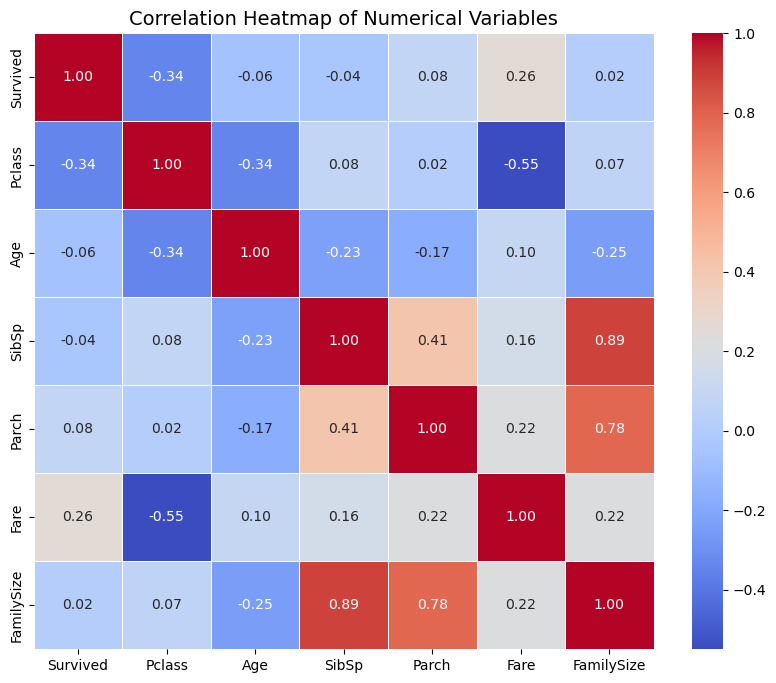

In [51]:
# Create a heatmap to show correlation between numerical variables
plt.figure(figsize=(10, 8))

numeric_df = df.select_dtypes(include=['float64', 'int64']).drop(columns=['PassengerId'])
correlation_matrix = numeric_df.corr()

sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap of Numerical Variables', fontsize=14)

**Q9. Identify which passenger class paid the highest fare on average.**
- The analysis shows that 1st Class passengers paid the highest average fare by a significant margin.

**Q10. Write at least 5 insights from the dataset based on your visualizations.**
- **Gender & Age Priority:** Women and children had a much higher survival rate than men, showing a clear rescue priority.
- **Class Matters:** 1st-class passengers were far more likely to survive than those in 3rd class.
- **Fare Inequality:** Ticket prices varied widely, with 1st-class fares much higher than 3rd class, reflecting a big wealth gap.
- **Age Distribution:** Most passengers were young adults (20–40), while elderly passengers had lower survival rates.
- **Family Size Effect:** Passengers in large families (5+) had lower survival chances, likely due to coordination difficulties during evacuation.